In [ ]:
from dataset import load_tif_image
import matplotlib.pyplot as plt
_ = load_tif_image("data/raw/1.tif")

I0000 00:00:1790176784.010466    1979 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
W0000 00:00:1790176792.886872    2081 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1790176793.794257    1979 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Original shape: (1024, 1024)
Min: 0.0
Max: 1.0
Final mask shape: (256, 256)
Mask values: [0 1]
Actin pixels: 675
Actin percentage: 1.02996826171875


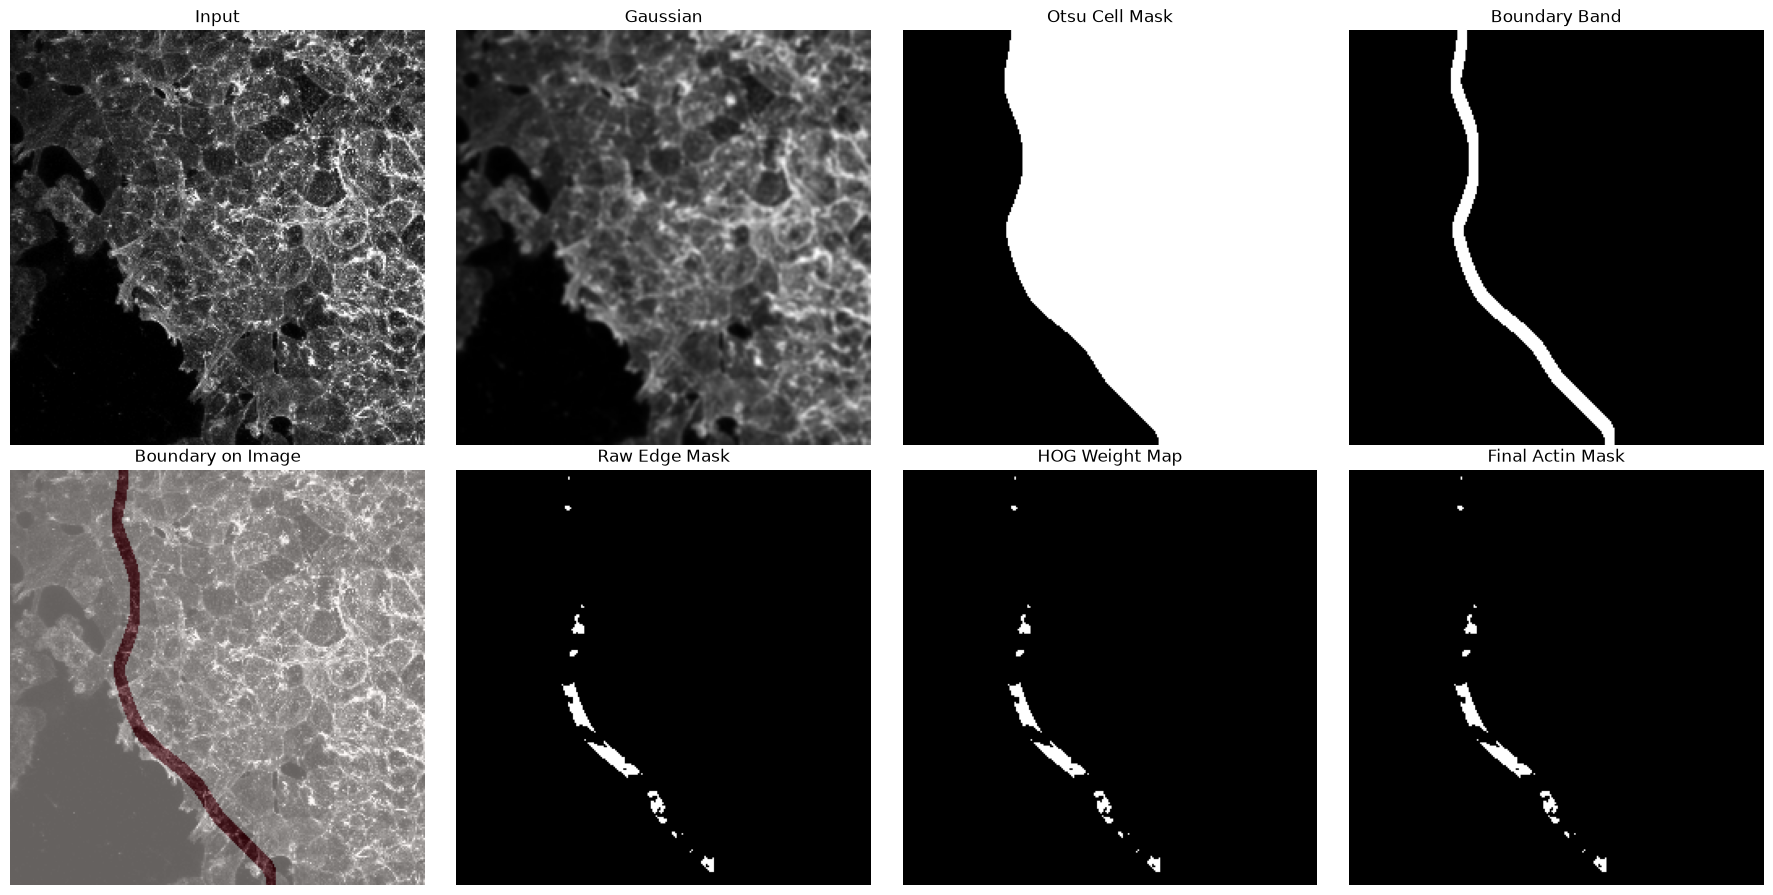

In [ ]:
from dataset import load_tif_image, preprocess_image
import matplotlib.pyplot as plt
import cv2
import numpy as np
import config

# Load image
path = "data/raw/1.tif"

img = load_tif_image(path)

print("Original shape:", img.shape)
print("Min:", img.min())
print("Max:", img.max())


# Resize exactly as dataset.py does
img_resized = cv2.resize(
    img,
    config.IMAGE_SIZE,
    interpolation=cv2.INTER_LINEAR
)


# Generate mask
result = preprocess_image(img_resized)


# Extract results
smoothed = result["smoothed"]
footprint = result["footprint"]
boundary_band = result["boundary_band"]
edge_mask_raw = result["edge_mask_raw"]
hog_weight_map = result["hog_weight_map"]
edge_mask = result["edge_mask"]


# Print mask information
print("Final mask shape:", edge_mask.shape)
print("Mask values:", np.unique(edge_mask))
print("Actin pixels:", np.sum(edge_mask))
print(
    "Actin percentage:",
    100 * np.mean(edge_mask)
)


# Plot everything
fig, axes = plt.subplots(
    2, 4,
    figsize=(18, 9)
)


axes[0, 0].imshow(
    img_resized,
    cmap="gray"
)
axes[0, 0].set_title("Input")


axes[0, 1].imshow(
    smoothed,
    cmap="gray"
)
axes[0, 1].set_title("Gaussian")


axes[0, 2].imshow(
    footprint,
    cmap="gray"
)
axes[0, 2].set_title("Otsu Cell Mask")


axes[0, 3].imshow(
    boundary_band,
    cmap="gray"
)
axes[0, 3].set_title("Boundary Band")


axes[1, 0].imshow(
    img_resized,
    cmap="gray"
)
axes[1, 0].imshow(
    boundary_band,
    cmap="Reds",
    alpha=0.4
)
axes[1, 0].set_title("Boundary on Image")


axes[1, 1].imshow(
    edge_mask_raw,
    cmap="gray"
)
axes[1, 1].set_title("Raw Edge Mask")


axes[1, 2].imshow(
    hog_weight_map,
    cmap="gray"
)
axes[1, 2].set_title("HOG Weight Map")


axes[1, 3].imshow(
    edge_mask,
    cmap="gray"
)
axes[1, 3].set_title("Final Actin Mask")


for ax in axes.ravel():
    ax.axis("off")


plt.tight_layout()
plt.show()